<a href="https://colab.research.google.com/github/Nouman14-ai/Computer_Vision_Basics/blob/main/Nouman_22F_3788_A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone https://github.com/Nouman14-ai/Computer_Vision_Basics.git

Cloning into 'Computer_Vision_Basics'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 25 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 139.21 KiB | 1.11 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [3]:
import os
os.chdir('Computer_Vision_Basics')

# **Computer Vision Basics Assignment**
# **Name: Nouman Shabbir**
# **Roll No: 22F-3788**


# **QUESTION 1: IMAGE ENHANCEMENT**


## **Part (a): Histogram Equalization from Scratch**


### **Step 2.1 — Import Required Libraries**

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

### **Step 2.2 — Load Two Images**

In [6]:
low_img = cv2.imread('test_images/low_contrast.jpg', 0)
dark_img = cv2.imread('test_images/dark_image.jpg', 0)

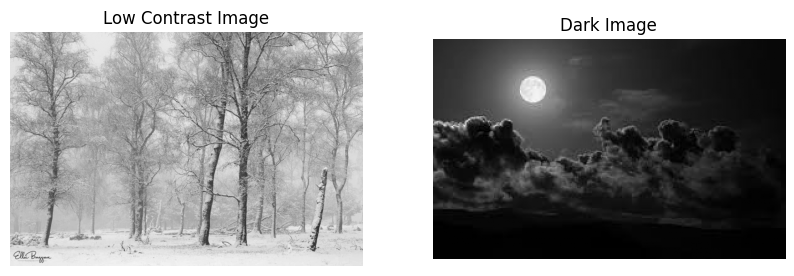

In [7]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(low_img, cmap='gray')
plt.title("Low Contrast Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(dark_img, cmap='gray')
plt.title("Dark Image")
plt.axis('off')

plt.show()

### **Step 2.3 — Implement Histogram Equalization Function (From Scratch)**

In [8]:
def histogram_equalization(image):
    # Step 1: Compute histogram
    hist = np.zeros(256)
    for pixel in image.flatten():
        hist[pixel] += 1

    # Step 2: Normalize histogram (PDF)
    pdf = hist / np.sum(hist)

    # Step 3: Compute CDF
    cdf = np.cumsum(pdf)

    # Step 4: Create transformation mapping
    mapping = np.round(cdf * 255).astype(np.uint8)

    # Step 5: Map original image pixels
    equalized_image = mapping[image]

    return equalized_image, hist, mapping

### **Step 2.4 — Apply Function**

In [9]:
low_eq, low_hist, low_map = histogram_equalization(low_img)
dark_eq, dark_hist, dark_map = histogram_equalization(dark_img)

### **Step 2.5 — Display Before/After**

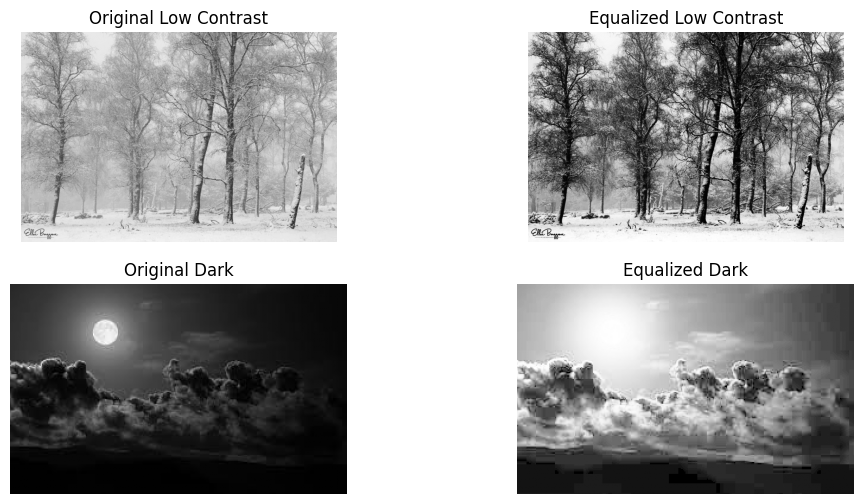

In [10]:
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plt.imshow(low_img, cmap='gray')
plt.title("Original Low Contrast")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(low_eq, cmap='gray')
plt.title("Equalized Low Contrast")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(dark_img, cmap='gray')
plt.title("Original Dark")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(dark_eq, cmap='gray')
plt.title("Equalized Dark")
plt.axis('off')

plt.show()

### **Step 2.6 — Print Mapping Array**

In [11]:
print("Transformation Mapping for Low Contrast Image:")
print(low_map)

Transformation Mapping for Low Contrast Image:
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   1   1   1   1   1   1   1   1   2
   2   2   2   2   3   3   3   3   3   4   4   4   4   4   5   5   5   6
   6   6   6   6   7   7   7   8   8   8   9   9  10  10  10  11  11  12
  12  13  13  14  15  15  16  16  17  18  19  20  20  21  22  23  24  25
  26  27  28  30  31  33  34  36  37  39  41  43  45  47  49  51  53  56
  59  62  65  67  70  72  75  79  83  86  90  93  96 100 104 109 113 117
 121 125 128 133 137 142 145 150 153 156 160 165 169 173 177 180 183 186
 189 192 195 197 199 201 203 206 208 211 212 215 216 218 221 223 225 227
 229 230 232 234 236 238 240 241 243 245 247 249 250 252 253 254 254 255
 255

### **Step 2.7 — Compare With OpenCV (For Verification Only)**

In [12]:
low_cv = cv2.equalizeHist(low_img)
dark_cv = cv2.equalizeHist(dark_img)

In [13]:
print("Difference (Low Image):", np.mean(np.abs(low_eq - low_cv)))
print("Difference (Dark Image):", np.mean(np.abs(dark_eq - dark_cv)))

Difference (Low Image): 0.0
Difference (Dark Image): 1.02570223601496
